<a href="https://colab.research.google.com/github/Rohitdesu/Hybrid-Classical-Quantum-Framework/blob/main/hybrid_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install torch torchvision scikit-learn matplotlib pillow


In [5]:
code = r'''
import argparse
import json
import math
import random
import re
import time
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import models, transforms


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def find_class_name(path: Path) -> str:
    parts = [part.lower() for part in path.parts]
    if any("malignant" in part for part in parts):
        return "malignant"
    if any("benign" in part for part in parts):
        return "benign"
    raise ValueError(f"Could not infer class from path: {path}")


def find_magnification(path: Path) -> str:
    for part in reversed(path.parts):
        match = re.search(r"(\d{2,4})\s*[xX]", part)
        if match:
            return f"{match.group(1)}X"
    return "unknown"


def scan_dataset(root: Path) -> List[Dict[str, str]]:
    records: List[Dict[str, str]] = []
    for file_path in root.rglob("*"):
        if not file_path.is_file() or file_path.suffix.lower() not in VALID_EXTENSIONS:
            continue
        try:
            label_name = find_class_name(file_path)
        except ValueError:
            continue
        records.append(
            {
                "path": str(file_path),
                "label_name": label_name,
                "label": 1 if label_name == "malignant" else 0,
                "magnification": find_magnification(file_path),
            }
        )
    if not records:
        raise RuntimeError(
            f"No image files found under {root}. Expected benign/malignant folders."
        )
    return records


def stratified_split(
    records: Sequence[Dict[str, str]],
    seed: int,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15,
) -> Tuple[List[Dict[str, str]], List[Dict[str, str]], List[Dict[str, str]]]:
    if not math.isclose(train_ratio + val_ratio + test_ratio, 1.0, rel_tol=1e-6):
        raise ValueError("Split ratios must sum to 1.0")

    strata = [f"{item['label_name']}::{item['magnification']}" for item in records]
    indices = list(range(len(records)))
    train_idx, temp_idx = train_test_split(
        indices,
        test_size=(1.0 - train_ratio),
        random_state=seed,
        shuffle=True,
        stratify=strata,
    )

    temp_records = [records[i] for i in temp_idx]
    temp_strata = [f"{item['label_name']}::{item['magnification']}" for item in temp_records]
    relative_val_ratio = val_ratio / (val_ratio + test_ratio)
    val_rel_idx, test_rel_idx = train_test_split(
        list(range(len(temp_idx))),
        test_size=(1.0 - relative_val_ratio),
        random_state=seed,
        shuffle=True,
        stratify=temp_strata,
    )

    val_idx = [temp_idx[i] for i in val_rel_idx]
    test_idx = [temp_idx[i] for i in test_rel_idx]
    train_records = [records[i] for i in train_idx]
    val_records = [records[i] for i in val_idx]
    test_records = [records[i] for i in test_idx]
    return train_records, val_records, test_records


class AddGaussianNoise:
    def __init__(self, sigma_range: Tuple[float, float] = (0.01, 0.03), p: float = 0.2):
        self.sigma_range = sigma_range
        self.p = p

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        if torch.rand(1).item() > self.p:
            return tensor
        sigma = random.uniform(*self.sigma_range)
        noise = torch.randn_like(tensor) * sigma
        return torch.clamp(tensor + noise, 0.0, 1.0)


class RandomRightAngleRotation:
    def __init__(self, p: float = 0.5):
        self.p = p

    def __call__(self, image: Image.Image) -> Image.Image:
        if random.random() > self.p:
            return image
        angle = random.choice([0, 90, 180, 270])
        return image.rotate(angle)


def build_transforms(image_size: int = 224) -> Tuple[transforms.Compose, transforms.Compose]:
    train_tfms = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            RandomRightAngleRotation(p=0.5),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.ToTensor(),
            AddGaussianNoise(p=0.2),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    eval_tfms = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )
    return train_tfms, eval_tfms


class HistopathologyDataset(Dataset):
    def __init__(self, records: Sequence[Dict[str, str]], transform: transforms.Compose):
        self.records = list(records)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int):
        item = self.records[index]
        image = Image.open(item["path"]).convert("RGB")
        image = self.transform(image)
        label = torch.tensor(item["label"], dtype=torch.float32)
        return image, label, item["path"], item["magnification"]


class QuantumInspiredProcessingLayer(nn.Module):
    def __init__(self, in_features: int = 2048, hidden_features: int = 512):
        super().__init__()
        self.map = nn.Linear(in_features, hidden_features)
        self.interact = nn.Linear(hidden_features, hidden_features)
        self.norm = nn.LayerNorm(hidden_features)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mapped = torch.tanh(self.map(x))
        interacted = torch.relu(self.interact(mapped))
        phase_encoded = torch.sin(interacted) + torch.cos(interacted)
        return self.dropout(self.norm(phase_encoded))


class FeatureSelfAttention(nn.Module):
    def __init__(self, embed_dim: int = 512, num_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        tokens = x.unsqueeze(1)
        attended, weights = self.attn(tokens, tokens, tokens, need_weights=True)
        output = self.norm(tokens + self.dropout(attended))
        return output.squeeze(1), weights


class HybridCancerClassifier(nn.Module):
    def __init__(self, dropout1: float = 0.35, dropout2: float = 0.30):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.quantum_layer = QuantumInspiredProcessingLayer(2048, 512)
        self.attention = FeatureSelfAttention(embed_dim=512, num_heads=8, dropout=0.1)
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout1),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout2),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        features = self.feature_extractor(x).flatten(1)
        enhanced = self.quantum_layer(features)
        attended, attention_weights = self.attention(enhanced)
        logits = self.classifier(attended).squeeze(1)
        return logits, attention_weights


def freeze_backbone_for_speed(model: HybridCancerClassifier) -> None:
    for param in model.feature_extractor.parameters():
        param.requires_grad = False
    for name, module in model.feature_extractor.named_children():
        if name in {"7"}:
            for param in module.parameters():
                param.requires_grad = True


def build_optimizer(model: nn.Module, lr: float, weight_decay: float) -> torch.optim.Optimizer:
    params = [param for param in model.parameters() if param.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)


def build_scheduler(optimizer: torch.optim.Optimizer, epochs: int):
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


def make_weighted_sampler(records: Sequence[Dict[str, str]]) -> WeightedRandomSampler:
    labels = [item["label"] for item in records]
    counts = Counter(labels)
    weights = [1.0 / counts[label] for label in labels]
    weight_tensor = torch.DoubleTensor(weights)
    return WeightedRandomSampler(weight_tensor, num_samples=len(weight_tensor), replacement=True)


@dataclass
class EpochMetrics:
    loss: float
    accuracy: float
    precision: float
    recall: float
    f1: float
    specificity: float
    auc: float


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> Dict[str, float]:
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / max(1, (tn + fp))
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "auc": auc,
    }


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    scaler: torch.cuda.amp.GradScaler,
    train: bool,
) -> EpochMetrics:
    model.train(mode=train)
    losses: List[float] = []
    all_probs: List[float] = []
    all_labels: List[int] = []

    for images, labels, _, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                logits, _ = model(images)
                loss = criterion(logits, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        losses.append(loss.item())
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())

    metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
    return EpochMetrics(loss=float(np.mean(losses)), **metrics)


def save_curves(history: Dict[str, List[float]], output_dir: Path) -> None:
    epochs = list(range(1, len(history["train_loss"]) + 1))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(epochs, history["val_loss"], label="Val Loss", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_dir / "loss_curve.png", dpi=180)
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_accuracy"], label="Train Accuracy", linewidth=2)
    plt.plot(epochs, history["val_accuracy"], label="Val Accuracy", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(output_dir / "accuracy_curve.png", dpi=180)
    plt.close()


def save_confusion(y_true: np.ndarray, y_prob: np.ndarray, output_dir: Path) -> None:
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], ["Benign", "Malignant"])
    plt.yticks([0, 1], ["Benign", "Malignant"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(output_dir / "confusion_matrix.png", dpi=180)
    plt.close()


def evaluate_on_test(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[EpochMetrics, np.ndarray, np.ndarray, List[str], List[str]]:
    model.eval()
    losses: List[float] = []
    all_probs: List[float] = []
    all_labels: List[int] = []
    all_paths: List[str] = []
    all_magnifications: List[str] = []

    with torch.no_grad():
        for images, labels, paths, magnifications in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                logits, _ = model(images)
                loss = criterion(logits, labels)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            losses.append(loss.item())
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())
            all_paths.extend(paths)
            all_magnifications.extend(magnifications)

    metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
    return (
        EpochMetrics(loss=float(np.mean(losses)), **metrics),
        np.array(all_labels),
        np.array(all_probs),
        all_paths,
        all_magnifications,
    )


def summarize_split(records: Sequence[Dict[str, str]]) -> Dict[str, Dict[str, int]]:
    summary: Dict[str, Dict[str, int]] = {}
    for item in records:
        mag = item["magnification"]
        label = item["label_name"]
        summary.setdefault(mag, {"benign": 0, "malignant": 0})
        summary[mag][label] += 1
    return summary


def train_project(args: argparse.Namespace) -> None:
    set_seed(args.seed)
    root = Path(args.dataset_root)
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Scanning dataset under: {root}")
    records = scan_dataset(root)
    print(f"Found {len(records)} images.")

    train_records, val_records, test_records = stratified_split(records, seed=args.seed)
    split_summary = {
        "train": summarize_split(train_records),
        "val": summarize_split(val_records),
        "test": summarize_split(test_records),
    }
    with open(output_dir / "split_summary.json", "w", encoding="utf-8") as f:
        json.dump(split_summary, f, indent=2)

    train_tfms, eval_tfms = build_transforms(image_size=args.image_size)
    train_ds = HistopathologyDataset(train_records, train_tfms)
    val_ds = HistopathologyDataset(val_records, eval_tfms)
    test_ds = HistopathologyDataset(test_records, eval_tfms)

    train_sampler = make_weighted_sampler(train_records)
    loader_kwargs = {
        "num_workers": args.num_workers,
        "pin_memory": torch.cuda.is_available(),
        "persistent_workers": args.num_workers > 0,
    }
    train_loader = DataLoader(
        train_ds,
        batch_size=args.batch_size,
        sampler=train_sampler,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=args.batch_size,
        shuffle=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=args.batch_size,
        shuffle=False,
        **loader_kwargs,
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = HybridCancerClassifier(dropout1=args.dropout1, dropout2=args.dropout2)
    freeze_backbone_for_speed(model)
    model.to(device)

    pos_count = sum(item["label"] for item in train_records)
    neg_count = len(train_records) - pos_count
    pos_weight = torch.tensor([neg_count / max(1, pos_count)], device=device, dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = build_optimizer(model, lr=args.learning_rate, weight_decay=args.weight_decay)
    scheduler = build_scheduler(optimizer, epochs=args.epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

    history: Dict[str, List[float]] = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    best_val_acc = -1.0
    best_epoch = 0
    patience_counter = 0
    best_model_path = output_dir / "best_model.pt"

    start_time = time.time()
    for epoch in range(1, args.epochs + 1):
        train_metrics = run_epoch(
            model, train_loader, criterion, optimizer, device, scaler, train=True
        )
        val_metrics = run_epoch(
            model, val_loader, criterion, optimizer, device, scaler, train=False
        )
        scheduler.step()

        history["train_loss"].append(train_metrics.loss)
        history["val_loss"].append(val_metrics.loss)
        history["train_accuracy"].append(train_metrics.accuracy)
        history["val_accuracy"].append(val_metrics.accuracy)

        epoch_line = (
            f"Epoch {epoch:02d}/{args.epochs} | "
            f"train_loss={train_metrics.loss:.4f} train_acc={train_metrics.accuracy:.4f} | "
            f"val_loss={val_metrics.loss:.4f} val_acc={val_metrics.accuracy:.4f} "
            f"val_f1={val_metrics.f1:.4f}"
        )
        print(epoch_line)

        if val_metrics.accuracy > best_val_acc:
            best_val_acc = val_metrics.accuracy
            best_epoch = epoch
            patience_counter = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_accuracy": best_val_acc,
                    "args": vars(args),
                },
                best_model_path,
            )
        else:
            patience_counter += 1

        if patience_counter >= args.patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

        elapsed_minutes = (time.time() - start_time) / 60.0
        if elapsed_minutes >= args.max_train_minutes:
            print(
                f"Stopping after epoch {epoch} to stay within the "
                f"{args.max_train_minutes:.1f}-minute budget."
            )
            break

    train_duration = time.time() - start_time
    print(f"Training completed in {train_duration / 60.0:.2f} minutes.")

    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])

    test_metrics, y_true, y_prob, paths, mags = evaluate_on_test(
        model, test_loader, criterion, device
    )
    save_curves(history, output_dir)
    save_confusion(y_true, y_prob, output_dir)

    report = classification_report(
        y_true,
        (y_prob >= 0.5).astype(int),
        target_names=["benign", "malignant"],
        digits=4,
        zero_division=0,
    )
    with open(output_dir / "classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report)

    predictions = []
    for label, prob, path, mag in zip(y_true.tolist(), y_prob.tolist(), paths, mags):
        predictions.append(
            {
                "path": path,
                "magnification": mag,
                "true_label": int(label),
                "pred_label": int(prob >= 0.5),
                "malignant_probability": float(prob),
            }
        )
    with open(output_dir / "test_predictions.json", "w", encoding="utf-8") as f:
        json.dump(predictions, f, indent=2)

    result = {
        "paper_accuracy_target": 0.9234,
        "achieved_test_accuracy": test_metrics.accuracy,
        "achieved_test_precision": test_metrics.precision,
        "achieved_test_recall": test_metrics.recall,
        "achieved_test_f1": test_metrics.f1,
        "achieved_test_specificity": test_metrics.specificity,
        "achieved_test_auc": test_metrics.auc,
        "best_validation_accuracy": best_val_acc,
        "best_epoch": best_epoch,
        "epochs_ran": len(history["train_loss"]),
        "training_time_minutes": train_duration / 60.0,
        "dataset_size": len(records),
        "train_size": len(train_records),
        "val_size": len(val_records),
        "test_size": len(test_records),
    }
    with open(output_dir / "results_summary.json", "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print("\n========== Final Summary ==========")
    print(json.dumps(result, indent=2))
    print("\nClassification report:")
    print(report)


def build_arg_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(
        description="Colab-ready breast cancer histopathology training pipeline."
    )
    parser.add_argument(
        "--dataset-root",
        type=str,
        default="/content/drive/MyDrive/dataset_cancer_v1",
        help="Root folder containing benign/malignant image folders.",
    )
    parser.add_argument(
        "--output-dir",
        type=str,
        default="/content/drive/MyDrive/breast_cancer_project_outputs",
        help="Where checkpoints and plots will be written.",
    )
    parser.add_argument("--epochs", type=int, default=12)
    parser.add_argument("--patience", type=int, default=4)
    parser.add_argument("--batch-size", type=int, default=32)
    parser.add_argument("--num-workers", type=int, default=2)
    parser.add_argument("--image-size", type=int, default=224)
    parser.add_argument("--learning-rate", type=float, default=3e-4)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--dropout1", type=float, default=0.35)
    parser.add_argument("--dropout2", type=float, default=0.30)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--max-train-minutes", type=float, default=80.0)
    return parser


if __name__ == "__main__":
    parser = build_arg_parser()
    train_project(parser.parse_args())

'''

with open('/content/breast_cancer_colab_project.py', 'w', encoding='utf-8') as f:
    f.write(code)

print("File created at /content/breast_cancer_colab_project.py")


File created at /content/breast_cancer_colab_project.py


In [6]:
!python /content/breast_cancer_colab_project.py \
  --dataset-root /content/drive/MyDrive/dataset_cancer_v1 \
  --output-dir /content/drive/MyDrive/breast_cancer_project_outputs \
  --epochs 12 \
  --batch-size 32 \
  --num-workers 2 \
  --max-train-minutes 80


Scanning dataset under: /content/drive/MyDrive/dataset_cancer_v1
Found 7909 images.
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 169MB/s]
/content/breast_cancer_colab_project.py:495: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
/content/breast_cancer_colab_project.py:322: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
/content/breast_cancer_colab_project.py:322: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
Epoch 01/12 | train_lo

In [7]:
import json

with open('/content/drive/MyDrive/breast_cancer_project_outputs/results_summary.json', 'r') as f:
    data = json.load(f)

print(json.dumps(data, indent=2))


{
  "paper_accuracy_target": 0.9234,
  "achieved_test_accuracy": 0.9797809604043808,
  "achieved_test_precision": 0.9852941176470589,
  "achieved_test_recall": 0.9852941176470589,
  "achieved_test_f1": 0.9852941176470589,
  "achieved_test_specificity": 0.967654986522911,
  "achieved_test_auc": 0.9931293272025792,
  "best_validation_accuracy": 0.9881956155143339,
  "best_epoch": 10,
  "epochs_ran": 12,
  "training_time_minutes": 35.16836819251378,
  "dataset_size": 7909,
  "train_size": 5536,
  "val_size": 1186,
  "test_size": 1187
}


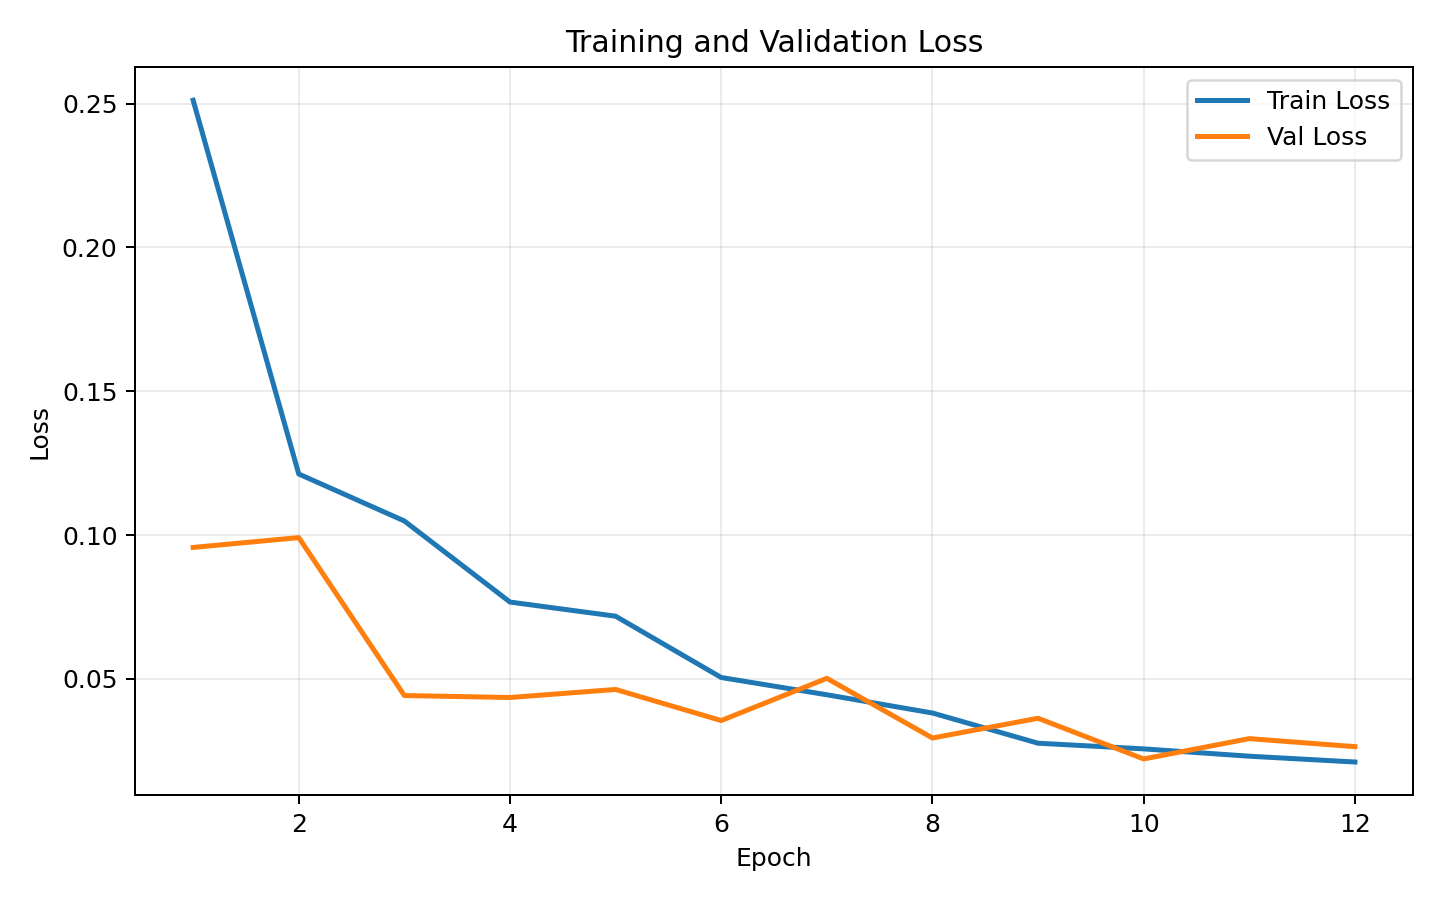

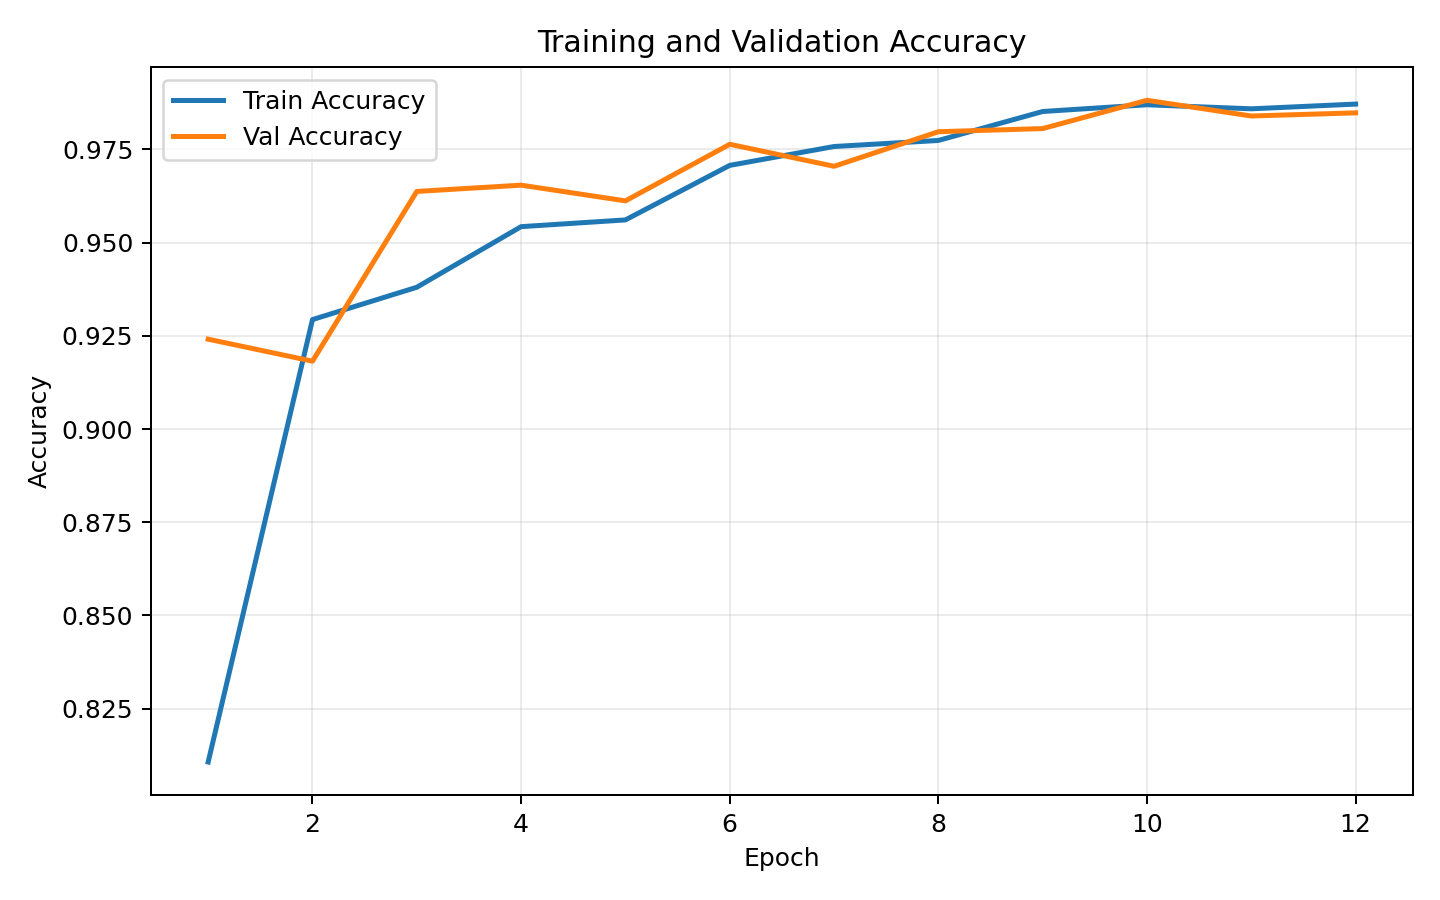

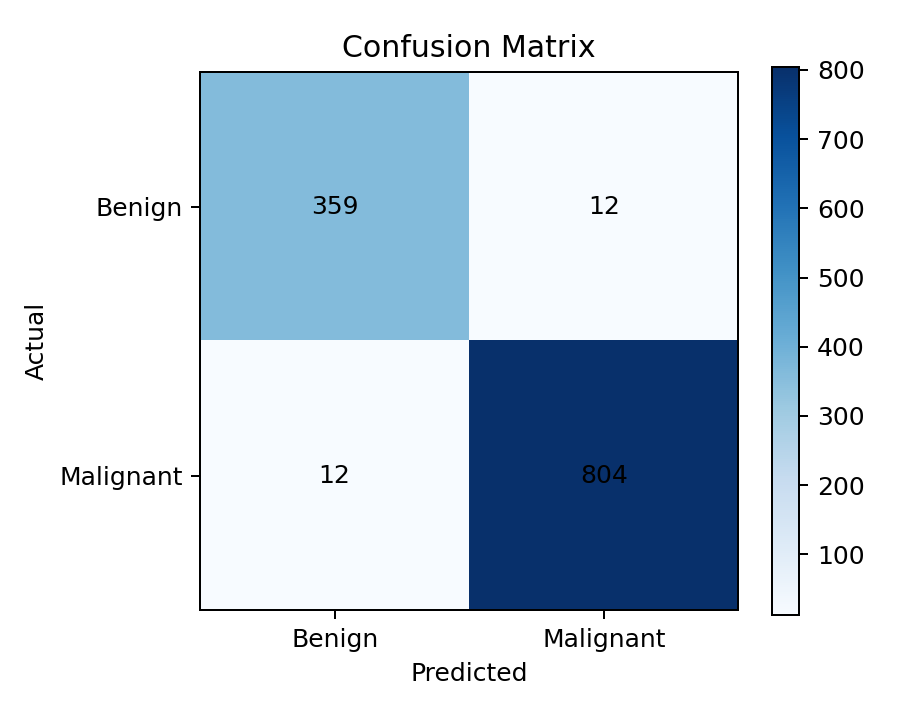

In [8]:
from IPython.display import Image, display

display(Image('/content/drive/MyDrive/breast_cancer_project_outputs/loss_curve.png'))
display(Image('/content/drive/MyDrive/breast_cancer_project_outputs/accuracy_curve.png'))
display(Image('/content/drive/MyDrive/breast_cancer_project_outputs/confusion_matrix.png'))


In [9]:
import os
model_path = "/content/drive/MyDrive/breast_cancer_project_outputs/best_model.pt"
print("Exists:", os.path.exists(model_path))
print("Path:", model_path)


Exists: True
Path: /content/drive/MyDrive/breast_cancer_project_outputs/best_model.pt


In [10]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class QuantumInspiredProcessingLayer(nn.Module):
    def __init__(self, in_features=2048, hidden_features=512):
        super().__init__()
        self.map = nn.Linear(in_features, hidden_features)
        self.interact = nn.Linear(hidden_features, hidden_features)
        self.norm = nn.LayerNorm(hidden_features)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        mapped = torch.tanh(self.map(x))
        interacted = torch.relu(self.interact(mapped))
        phase_encoded = torch.sin(interacted) + torch.cos(interacted)
        return self.dropout(self.norm(phase_encoded))

class FeatureSelfAttention(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        tokens = x.unsqueeze(1)
        attended, weights = self.attn(tokens, tokens, tokens, need_weights=True)
        output = self.norm(tokens + self.dropout(attended))
        return output.squeeze(1), weights

class HybridCancerClassifier(nn.Module):
    def __init__(self, dropout1=0.35, dropout2=0.30):
        super().__init__()
        backbone = models.resnet50(weights=None)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.quantum_layer = QuantumInspiredProcessingLayer(2048, 512)
        self.attention = FeatureSelfAttention(embed_dim=512, num_heads=8, dropout=0.1)
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout1),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        features = self.feature_extractor(x).flatten(1)
        enhanced = self.quantum_layer(features)
        attended, attention_weights = self.attention(enhanced)
        logits = self.classifier(attended).squeeze(1)
        return logits, attention_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridCancerClassifier().to(device)

ckpt_path = "/content/drive/MyDrive/breast_cancer_project_outputs/best_model.pt"
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Model loaded successfully")


Model loaded successfully


In [11]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = infer_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, _ = model(input_tensor)
        prob = torch.sigmoid(logits).item()

    pred_class = "malignant" if prob >= 0.5 else "benign"
    confidence = prob if pred_class == "malignant" else (1 - prob)

    actual_class = "unknown"
    lower_path = image_path.lower()
    if "malignant" in lower_path:
        actual_class = "malignant"
    elif "benign" in lower_path:
        actual_class = "benign"

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted: {pred_class} | Confidence: {confidence:.4f}")
    plt.show()

    print("Image path:", image_path)
    print("Predicted class:", pred_class)
    print("Confidence:", round(confidence, 4))
    print("Malignant probability:", round(prob, 4))
    print("Actual class:", actual_class)

    if actual_class != "unknown":
        print("Correct prediction:", pred_class == actual_class)


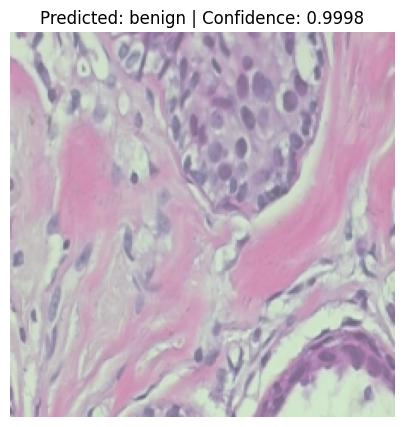

Image path: /content/drive/MyDrive/dataset_cancer_v1/classificacao_multiclasse/200X/adenosis/SOB_B_A-14-22549AB-200-001.png
Predicted class: benign
Confidence: 0.9998
Malignant probability: 0.0002
Actual class: unknown


In [12]:
test_image_path = "/content/drive/MyDrive/dataset_cancer_v1/classificacao_multiclasse/200X/adenosis/SOB_B_A-14-22549AB-200-001.png"
predict_image(test_image_path)
